# 05 — Compare Carbon Models: Evolution with Flat vs NIR

Runs NSGA-II evolution twice:
1. With the current flat/v1.5 carbon model
2. With the NIR-calibrated carbon model

Then compares the resulting Pareto fronts side-by-side.

Use small pop_size/generations for a quick comparison.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
from pathlib import Path
import time

# Handle running from both project root and notebooks/ directory
if "__file__" in dir():
    _root = Path(__file__).resolve().parent.parent
else:
    # In Jupyter: walk up until we find pyproject.toml
    _root = Path(".").resolve()
    if _root.name == "notebooks":
        _root = _root.parent
    elif not (_root / "pyproject.toml").exists():
        # Try parent
        if (_root.parent / "pyproject.toml").exists():
            _root = _root.parent

sys.path.insert(0, str(_root / "src"))

from estonia_landuse.optimizer.trainer import train
from estonia_landuse.simulator.config import default_config
from estonia_landuse.simulator.simulator import summarize_policy

OUTPUT_DIR = _root / "data" / "processed" / "learned_carbon"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Load data

In [2]:
features_df = pd.read_parquet(_root / "data/processed/v1/features_v1_derived.parquet")
if "peat_overlap_pct" not in features_df.columns:
    features_df["peat_overlap_pct"] = 0.0

print(f"Loaded {len(features_df)} cells")

# Feature columns for the prescriptor (numeric only, relevant for decisions)
FEATURE_COLUMNS = [
    "urban_pct", "agriculture_pct", "grassland_pct", "forest_pct",
    "wetland_pct", "water_pct", "naturalness_score", "carbon_score",
    "protected_overlap_pct", "wetland_suitability", "biodiversity_proxy",
    "opportunity_cost_proxy",
]
# Keep only columns that exist
FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if c in features_df.columns]
print(f"Using {len(FEATURE_COLUMNS)} features: {FEATURE_COLUMNS}")

Loaded 2806 cells
Using 12 features: ['urban_pct', 'agriculture_pct', 'grassland_pct', 'forest_pct', 'wetland_pct', 'water_pct', 'naturalness_score', 'carbon_score', 'protected_overlap_pct', 'wetland_suitability', 'biodiversity_proxy', 'opportunity_cost_proxy']


## Evolution parameters

Using small values for quick iteration. Increase for better results.

In [3]:
# Quick run: ~30 seconds each
POP_SIZE = 40
N_GENERATIONS = 30
HIDDEN_SIZE = 16

# For a serious comparison, use:
# POP_SIZE = 100
# N_GENERATIONS = 100

## Run 1: Flat carbon model (current default)

In [4]:
config_flat = default_config()
config_flat["carbon_model"] = "flat"

print(f"Running evolution with FLAT carbon model...")
print(f"  pop_size={POP_SIZE}, generations={N_GENERATIONS}")
t0 = time.time()

pop_flat = train(
    context=features_df,
    feature_columns=FEATURE_COLUMNS,
    pop_size=POP_SIZE,
    n_generations=N_GENERATIONS,
    hidden_size=HIDDEN_SIZE,
    config=config_flat,
    use_seeds=True,
    verbose=True,
)

t_flat = time.time() - t0
print(f"\nFlat model done in {t_flat:.1f}s")
print(f"Front-0 size: {sum(1 for p in pop_flat if p.rank == 0)}")

Running evolution with FLAT carbon model...
  pop_size=40, generations=30


C:\Users\risto\projects\et-landuse-neuroevolution\src\estonia_landuse\optimizer\seeds.py:42: RuntimeWarning: invalid value encountered in divide
  current_norm = np.where(current_sum > 0, current / current_sum, 0.25)


Created 4 seed prescriptors
Gen  10 | Front-0:  40 | Avg: bio=0.0474 carbon=0.0375 cost=1.4682 change=41.0%
Gen  20 | Front-0:  40 | Avg: bio=0.0634 carbon=0.0577 cost=1.5287 change=41.0%
Gen  30 | Front-0:  40 | Avg: bio=0.0711 carbon=0.0707 cost=1.3417 change=41.8%

Flat model done in 11.0s
Front-0 size: 40


## Run 2: NIR-calibrated carbon model

In [5]:
config_nir = default_config()
config_nir["carbon_model"] = "nir"

print(f"Running evolution with NIR carbon model...")
print(f"  pop_size={POP_SIZE}, generations={N_GENERATIONS}")
t0 = time.time()

pop_nir = train(
    context=features_df,
    feature_columns=FEATURE_COLUMNS,
    pop_size=POP_SIZE,
    n_generations=N_GENERATIONS,
    hidden_size=HIDDEN_SIZE,
    config=config_nir,
    use_seeds=True,
    verbose=True,
)

t_nir = time.time() - t0
print(f"\nNIR model done in {t_nir:.1f}s")
print(f"Front-0 size: {sum(1 for p in pop_nir if p.rank == 0)}")

Running evolution with NIR carbon model...
  pop_size=40, generations=30


C:\Users\risto\projects\et-landuse-neuroevolution\src\estonia_landuse\optimizer\seeds.py:42: RuntimeWarning: invalid value encountered in divide
  current_norm = np.where(current_sum > 0, current / current_sum, 0.25)


Created 4 seed prescriptors
Gen  10 | Front-0:  40 | Avg: bio=0.0411 carbon=-0.0140 cost=1.2656 change=40.3%
Gen  20 | Front-0:  40 | Avg: bio=0.0620 carbon=-0.0070 cost=1.4723 change=44.0%
Gen  30 | Front-0:  40 | Avg: bio=0.0779 carbon=0.0113 cost=1.7000 change=44.2%

NIR model done in 15.2s
Front-0 size: 40


## Cross-evaluate: score each population with BOTH models

This is the key comparison: how do policies evolved under one model
perform when evaluated by the other?

In [6]:
def evaluate_population(population, context, config, label=""):
    """Evaluate all individuals and return their metrics."""
    features = context[FEATURE_COLUMNS].values.astype(np.float32)
    feat_mean = features.mean(axis=0)
    feat_std = features.std(axis=0)
    feat_std[feat_std == 0] = 1.0
    features_norm = (features - feat_mean) / feat_std

    results = []
    for i, p in enumerate(population):
        if p.rank != 0:
            continue  # only evaluate Pareto front
        target_fractions = p.prescribe(features_norm)
        summary = summarize_policy(context, target_fractions, config)
        summary["individual"] = i
        summary["label"] = label
        results.append(summary)

    return pd.DataFrame(results)


# Evaluate flat-evolved policies with BOTH carbon models
flat_eval_flat = evaluate_population(pop_flat, features_df, config_flat, "flat_policy+flat_eval")
flat_eval_nir = evaluate_population(pop_flat, features_df, config_nir, "flat_policy+nir_eval")

# Evaluate NIR-evolved policies with BOTH carbon models
nir_eval_flat = evaluate_population(pop_nir, features_df, config_flat, "nir_policy+flat_eval")
nir_eval_nir = evaluate_population(pop_nir, features_df, config_nir, "nir_policy+nir_eval")

all_results = pd.concat([flat_eval_flat, flat_eval_nir, nir_eval_flat, nir_eval_nir], ignore_index=True)
all_results.to_parquet(OUTPUT_DIR / "evolution_comparison.parquet", index=False)

print(f"Cross-evaluation complete: {len(all_results)} evaluations")
print(f"\nSummary by group:")
print(all_results.groupby("label")[["biodiversity_gain", "carbon_gain", "cost", "changed_pct"]].mean())

Cross-evaluation complete: 160 evaluations

Summary by group:
                       biodiversity_gain  carbon_gain      cost  changed_pct
label                                                                       
flat_policy+flat_eval           0.071085     0.070691  1.341699     0.418137
flat_policy+nir_eval            0.071085     0.001302  1.341699     0.418137
nir_policy+flat_eval            0.077949     0.073636  1.700044     0.442037
nir_policy+nir_eval             0.077949     0.011268  1.700044     0.442037


## Visualize Pareto fronts

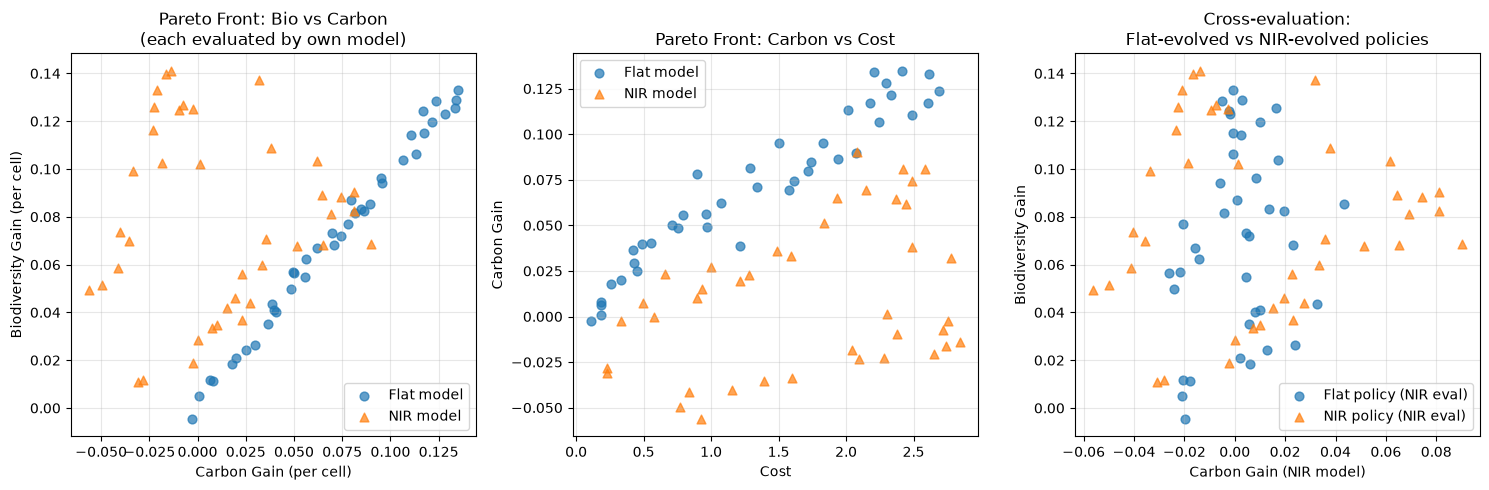

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Biodiversity vs Carbon (same-model evaluation)
ax = axes[0]
ax.scatter(flat_eval_flat["carbon_gain"], flat_eval_flat["biodiversity_gain"],
           alpha=0.7, label="Flat model", marker="o", s=40)
ax.scatter(nir_eval_nir["carbon_gain"], nir_eval_nir["biodiversity_gain"],
           alpha=0.7, label="NIR model", marker="^", s=40)
ax.set_xlabel("Carbon Gain (per cell)")
ax.set_ylabel("Biodiversity Gain (per cell)")
ax.set_title("Pareto Front: Bio vs Carbon\n(each evaluated by own model)")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Carbon vs Cost (same-model evaluation)
ax = axes[1]
ax.scatter(flat_eval_flat["cost"], flat_eval_flat["carbon_gain"],
           alpha=0.7, label="Flat model", marker="o", s=40)
ax.scatter(nir_eval_nir["cost"], nir_eval_nir["carbon_gain"],
           alpha=0.7, label="NIR model", marker="^", s=40)
ax.set_xlabel("Cost")
ax.set_ylabel("Carbon Gain")
ax.set_title("Pareto Front: Carbon vs Cost")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Cross-evaluation — how does flat policy score under NIR?
ax = axes[2]
ax.scatter(flat_eval_nir["carbon_gain"], flat_eval_nir["biodiversity_gain"],
           alpha=0.7, label="Flat policy (NIR eval)", marker="o", s=40)
ax.scatter(nir_eval_nir["carbon_gain"], nir_eval_nir["biodiversity_gain"],
           alpha=0.7, label="NIR policy (NIR eval)", marker="^", s=40)
ax.set_xlabel("Carbon Gain (NIR model)")
ax.set_ylabel("Biodiversity Gain")
ax.set_title("Cross-evaluation:\nFlat-evolved vs NIR-evolved policies")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary statistics

In [8]:
print("=" * 70)
print("EVOLUTION COMPARISON SUMMARY")
print("=" * 70)

print("\n1. FLAT-evolved policies evaluated by FLAT model:")
print(f"   Carbon: {flat_eval_flat['carbon_gain'].mean():.4f}")
print(f"   Biodiversity: {flat_eval_flat['biodiversity_gain'].mean():.4f}")
print(f"   Cost: {flat_eval_flat['cost'].mean():.4f}")
print(f"   Change%: {flat_eval_flat['changed_pct'].mean():.1%}")

print("\n2. NIR-evolved policies evaluated by NIR model:")
print(f"   Carbon: {nir_eval_nir['carbon_gain'].mean():.4f}")
print(f"   Biodiversity: {nir_eval_nir['biodiversity_gain'].mean():.4f}")
print(f"   Cost: {nir_eval_nir['cost'].mean():.4f}")
print(f"   Change%: {nir_eval_nir['changed_pct'].mean():.1%}")

print("\n3. CROSS-EVALUATION (key insight):")
print("   Flat-evolved policies scored by NIR model:")
print(f"   Carbon: {flat_eval_nir['carbon_gain'].mean():.4f}")
print("   NIR-evolved policies scored by Flat model:")
print(f"   Carbon: {nir_eval_flat['carbon_gain'].mean():.4f}")

print("\n4. Interpretation:")
diff = nir_eval_nir['carbon_gain'].mean() - flat_eval_nir['carbon_gain'].mean()
if diff > 0:
    print(f"   NIR-evolved policies achieve {diff:.4f} MORE carbon gain")
    print("   under NIR evaluation than flat-evolved policies.")
    print("   → The NIR model finds different (better?) carbon strategies.")
else:
    print(f"   Flat-evolved policies are within {abs(diff):.4f} of NIR-evolved")
    print("   → Models agree on optimal strategies (just differ in scale).")

print(f"\n5. Runtime: Flat={t_flat:.1f}s, NIR={t_nir:.1f}s")

EVOLUTION COMPARISON SUMMARY

1. FLAT-evolved policies evaluated by FLAT model:
   Carbon: 0.0707
   Biodiversity: 0.0711
   Cost: 1.3417
   Change%: 41.8%

2. NIR-evolved policies evaluated by NIR model:
   Carbon: 0.0113
   Biodiversity: 0.0779
   Cost: 1.7000
   Change%: 44.2%

3. CROSS-EVALUATION (key insight):
   Flat-evolved policies scored by NIR model:
   Carbon: 0.0013
   NIR-evolved policies scored by Flat model:
   Carbon: 0.0736

4. Interpretation:
   NIR-evolved policies achieve 0.0100 MORE carbon gain
   under NIR evaluation than flat-evolved policies.
   → The NIR model finds different (better?) carbon strategies.

5. Runtime: Flat=11.0s, NIR=15.2s
